# Evaluating Model Performance

Our goal is to rigorously assess how well our baseline model performs and identify areas for improvement.

### 1. Import Libraries

In [12]:
# import libraries
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model

### 2. Load Model and Data
To evaluate our model, we first need to load the trained model from the file where we saved it. We also need to load the test data, which the model has not seen before. This will allow us to get an unbiased assessment of its performance.

In [19]:
# load model and data
model = load_model('../results/baseline_model.keras')
X_test = np.load('../results/X_test.npy')
y_test = np.load('../results/y_test.npy')
history_data = np.load('../results/training_history.npy', allow_pickle=True).item()

### 3. Make Predictions
Now that we have our model and test data loaded, we can use the model to make predictions on the test set. This will give us the model's output for each of the images in our test set, which we can then compare to the true labels to evaluate the model's performance.

In [14]:
# Convert single-channel grayscale to 3-channel image
X_test_rgb = np.repeat(X_test, 3, axis=-1)

# Make predictions
pred = model.predict(X_test_rgb)
y_pred = np.argmax(pred, axis=1) # Because the output shows probabilities for each class, we need to take the index of the highest probability as the predicted class.

50/50 [==============================] - 1s 27ms/step


### 4. Generate Classification Report
A classification report is a key metric for evaluating a classification model. It provides a detailed breakdown of the model's performance for each class, including precision, recall, and F1-score. This helps us understand not just the overall accuracy, but also how well the model is performing on each specific type of tumor.

In [15]:
# generate classification report
target_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
report = classification_report(y_test, y_pred, target_names=target_names)
print(report)
# f1-score = 2 * (precision * recall) / (precision + recall)
# Save the report to a file
with open('../results/classification_report.txt', 'w') as f:
    f.write(report)

              precision    recall  f1-score   support

      glioma       0.91      0.76      0.83       400
  meningioma       0.86      0.87      0.86       400
     notumor       0.87      0.99      0.93       400
   pituitary       0.94      0.95      0.95       400

    accuracy                           0.89      1600
   macro avg       0.90      0.89      0.89      1600
weighted avg       0.90      0.89      0.89      1600



### 5. Generate Confusion Matrix
A confusion matrix is a great way to visualize the performance of a classification model. It shows a table with the true labels versus the predicted labels, which helps us see exactly where the model is getting confused. For example, we can see if it's frequently misclassifying one type of tumor as another.

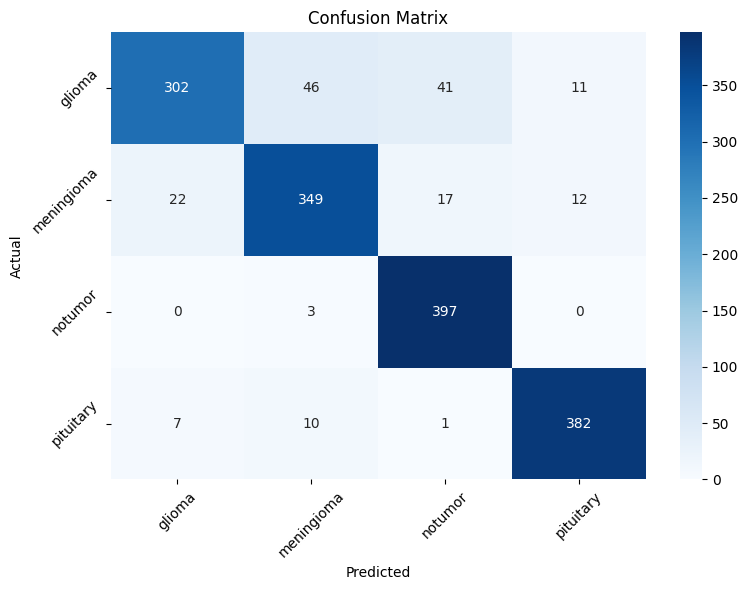

In [16]:
# generate confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.savefig('../results/confusion_matrix.png')
plt.show()

### 6. Plot Training History
Plotting the model's accuracy and loss over the training epochs is crucial for diagnosing its behavior. These plots help us identify issues like overfitting, where the model performs well on training data but poorly on new, unseen data. By visualizing the training and validation curves, we can see if they diverge, which is a classic sign of overfitting.

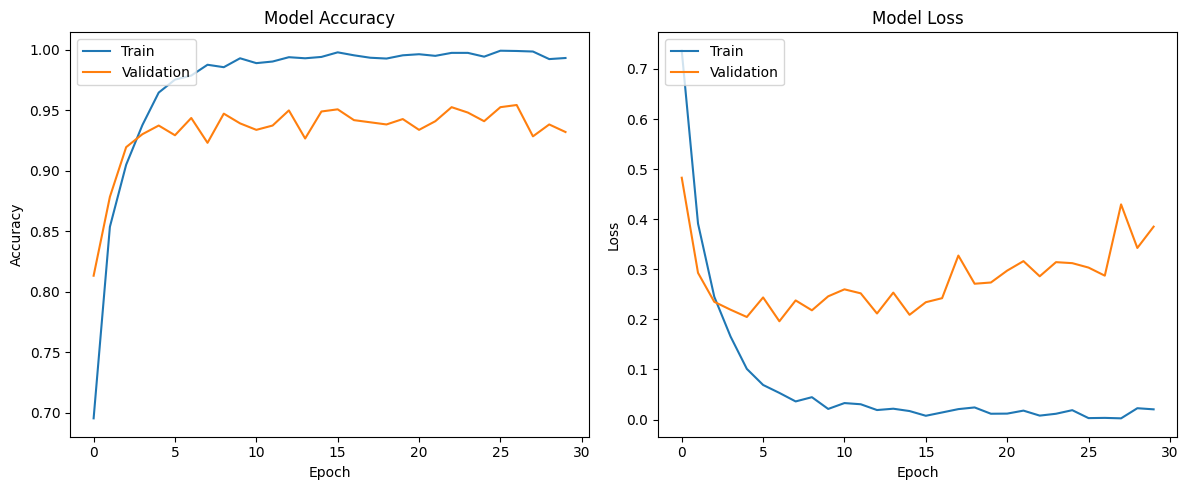

In [20]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_data['accuracy'])
plt.plot(history_data['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_data['loss'])
plt.plot(history_data['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

## From the graphs we can see that model is overfitting because the accuracy reaches to 100% and also loss is approximately 0.00 but we can't see the same performance in validation data. So it shows clear signs of overfitting. We will solve it with data augmentation.